In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation
from keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [4]:
#download the weather images and put them in a directory
path = os.path.join(r"C:\Users\april\Machine Learning", "Multi-class Weather Dataset")
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [5]:
datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


In [6]:
inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [7]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 60, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size-1,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size-1,
)

C:\Users\april\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5496 - loss: 0.1317 - val_accuracy: 0.6562 - val_loss: 0.1072
Epoch 2/60
 2/27 ━━━━━━━━━━━━━━━━━━━━ 15s 603ms/step - accuracy: 0.8047 - loss: 0.0778

C:\Users\april\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.7969 - loss: 0.0872 - val_accuracy: 0.6771 - val_loss: 0.1070
Epoch 3/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 701ms/step - accuracy: 0.7515 - loss: 0.0812 - val_accuracy: 0.6979 - val_loss: 0.1252
Epoch 4/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7656 - loss: 0.0896 - val_accuracy: 0.7396 - val_loss: 0.1170
Epoch 5/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 721ms/step - accuracy: 0.7730 - loss: 0.0773 - val_accuracy: 0.7865 - val_loss: 0.0811
Epoch 6/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.8594 - loss: 0.0629 - val_accuracy: 0.7448 - val_loss: 0.1143
Epoch 7/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 698ms/step - accuracy: 0.7993 - loss: 0.0682 - val_accuracy: 0.8385 - val_loss: 0.0636
Epoch 8/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.7188 - loss: 0.0775 - val_accuracy: 0.7708 - val_loss: 0.0751
Epoch 9/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 711ms/step - accuracy: 0.8339 - loss: 0.0604 - val_accuracy: 0.7865 - va

In [8]:
results = pd.DataFrame(model.history.history)

## Model Evaluation

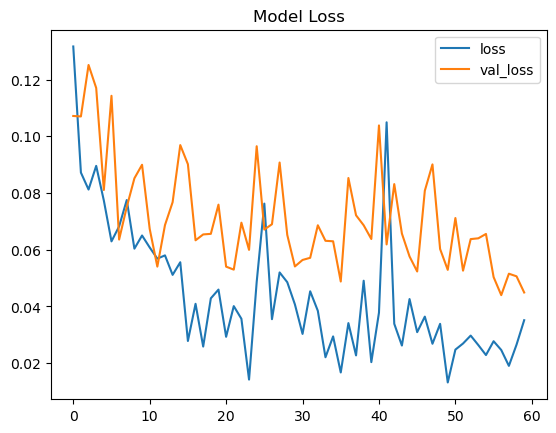

In [9]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

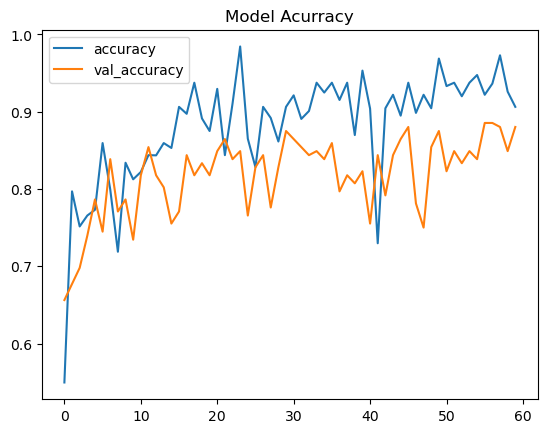

In [10]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [11]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.90625, Val_Accuracy: 0.8802083134651184
Loss: 0.035128504037857056, Val_Loss: 0.04490566626191139


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step


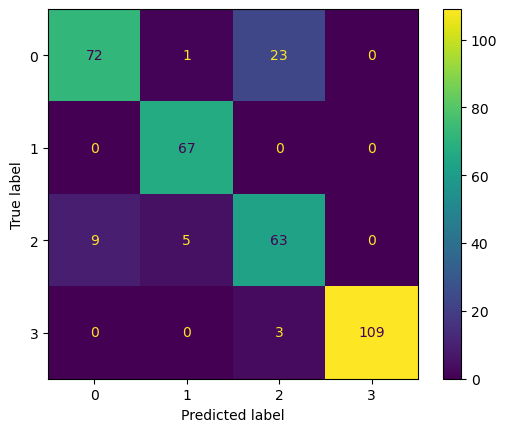

In [12]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [13]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


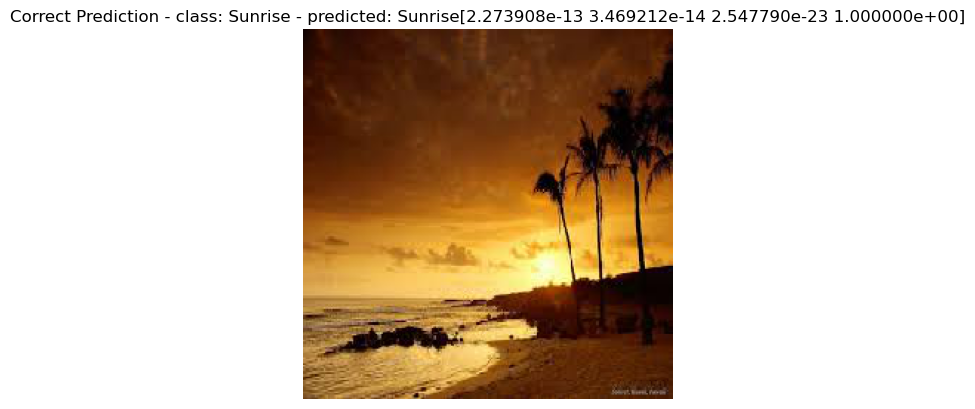

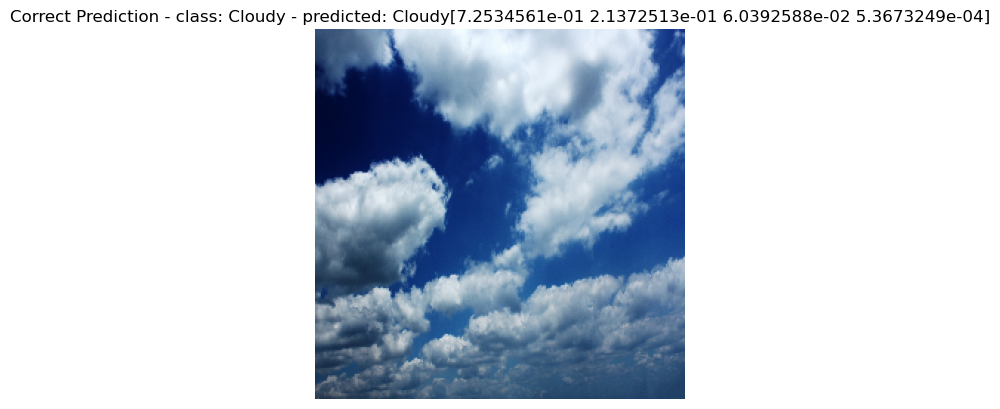

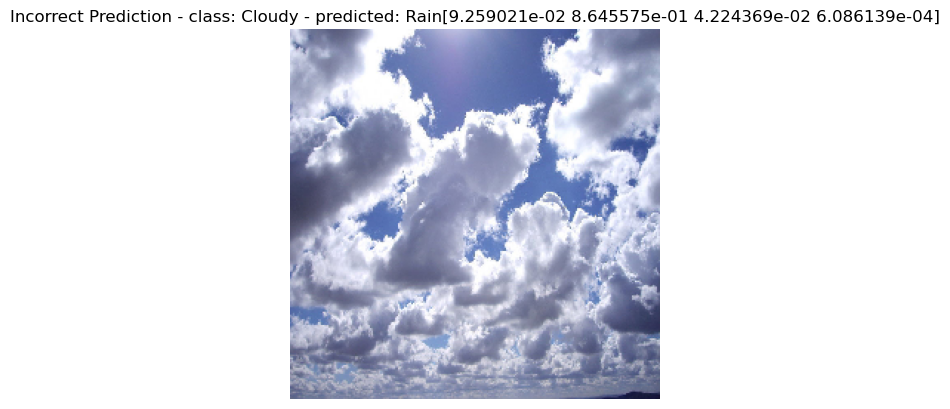

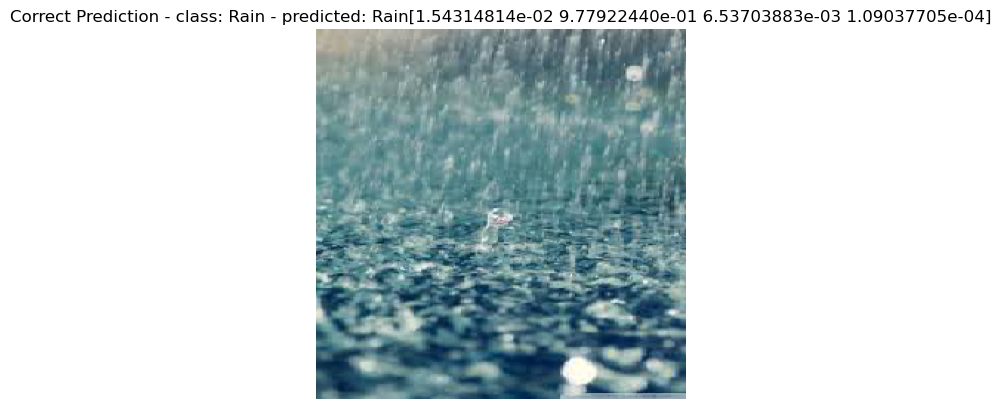

In [14]:
predict_one(model, 4) #<--you can show multiple pictures with this command. Just fill in the number you want to see.
